In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"data/Android_Permission.csv")

import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print("Success!")


Success!


In [63]:
print("=" * 48)
print("Android Permission - Data & Stats")
print("=" * 48)

print(f"Dataset Shape           : {df.shape[0]:,} rows × {df.shape[1]} columns")

duplicate_packages = df['Package'].duplicated().sum()
print(f"Duplicate Package IDs   : {duplicate_packages:,}")

duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows    : {duplicate_count:,} ({duplicate_count / len(df) * 100:.2f}%)")

metadata_cols = df.columns[:10].tolist()
target_col = 'Class'
permission_cols = [c for c in df.columns if c not in metadata_cols and c != target_col]

import textwrap
print("")
print("=" * 48)
print("Android Permission - Data Columns")
print("=" * 48)

print(f"General Data Columns ({len(metadata_cols)})")
print(textwrap.fill(", ".join(metadata_cols), width=80))

print(f"\nPermission Features ({len(permission_cols)} total)")
print(f"First 5 permission columns:")
print(textwrap.fill(", ".join(permission_cols[:5]), width=80))

Android Permission - Data & Stats
Dataset Shape           : 29,999 rows × 184 columns
Duplicate Package IDs   : 6,514
Total Duplicate Rows    : 2,689 (8.96%)

Android Permission - Data Columns
General Data Columns (10)
App, Package, Category, Description, Rating, Number of ratings, Price, Related
apps, Dangerous permissions count, Safe permissions count

Permission Features (173 total)
First 5 permission columns:
Default : Access DRM content. (S), Default : Access Email provider data (S),
Default : Access all system downloads (S), Default : Access download manager.
(S), Default : Advanced download manager functions. (S)


In [72]:
import textwrap
import pandas as pd

df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.dropna()

y = df_clean["Class"]
X = df_clean.drop(columns=["Class"])
X = X.select_dtypes(include=["number"])

constant_columns = [
    col for col in X.columns
    if X[col].nunique() <= 1
]
X = X.drop(columns=constant_columns)

print("=" * 48)
print("Cleaned Dataset Summary")
print("=" * 48)
duplicate_count = df.duplicated().sum()
missing_rows_count = len(df.drop_duplicates()) - len(df_clean)

print(f"Original Rows           : {len(df):,}")
print(f"Total Duplicate Rows    : {duplicate_count:,} ({duplicate_count / len(df) * 100:.2f}%)")
print(f"Rows with Missing Data  : {missing_rows_count:,}")
print(f"Cleaned Dataset         : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"All-Zero Columns Dropped: {len(constant_columns)}")
print(f"Final Features for ANN  : {X.shape[1]}")

print("\nFeature Columns (First 5):")
print(textwrap.fill(", ".join(X.columns[:5]), width=80))

print("\n" + "=" * 48)
print("Class Target Distribution (Cleaned Data)")
print("=" * 48)

class_counts = y.value_counts()
class_percentage = (y.value_counts(normalize=True) * 100).round(2)

summary_class = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentage
})

summary_class.index = summary_class.index.map({1: 'Malware (1)', 0: 'Benign (0)'})
summary_class.index.name = 'Class'

summary_class['Count'] = summary_class['Count'].apply(lambda x: f"{x:,}")
summary_class['Percentage (%)'] = summary_class['Percentage (%)'].apply(lambda x: f"{x:.2f}%")

summary_class.loc['Total'] = [f"{len(y):,}", "100.00%"]

print(summary_class.to_string())

Cleaned Dataset Summary
Original Rows           : 29,999
Total Duplicate Rows    : 2,689 (8.96%)
Rows with Missing Data  : 724
Cleaned Dataset         : 26,586 rows × 184 columns
All-Zero Columns Dropped: 22
Final Features for ANN  : 156

Feature Columns (First 5):
Rating, Number of ratings, Price, Dangerous permissions count, Safe permissions
count

Class Target Distribution (Cleaned Data)
              Count Percentage (%)
Class                             
Malware (1)  17,592         66.17%
Benign (0)    8,994         33.83%
Total        26,586        100.00%


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

print("Target classes present:", y.unique())
print(f"Total samples: {len(y):,}\n")

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train_raw)
X_test_norm = scaler.transform(X_test_raw)

print("=" * 48)
print("Dataset Splitting for Raw and Normalized Tests")
print("=" * 48)
print(f"Training set (Raw)        : {X_train_raw.shape[0]:,} samples × {X_train_raw.shape[1]} features")
print(f"Testing set (Raw)         : {X_test_raw.shape[0]:,} samples × {X_test_raw.shape[1]} features")
print(f"Training set (Normalized) : {X_train_norm.shape[0]:,} samples × {X_train_norm.shape[1]} features")
print(f"Testing set (Normalized)  : {X_test_norm.shape[0]:,} samples × {X_test_norm.shape[1]} features")

print("\nClass Proportion Verification:")
print(f"Train Malware ratio: {(y_train == 1).mean() * 100:.2f}%")
print(f"Test Malware ratio : {(y_test == 1).mean() * 100:.2f}%")


Target classes present: [0 1]
Total samples: 26,586

Dataset Splitting for Raw and Normalized Tests
Training set (Raw)        : 21,268 samples × 156 features
Testing set (Raw)         : 5,318 samples × 156 features
Training set (Normalized) : 21,268 samples × 156 features
Testing set (Normalized)  : 5,318 samples × 156 features

Class Proportion Verification:
Train Malware ratio: 66.17%
Test Malware ratio : 66.17%


In [65]:
import time
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def build_ann(hidden_layers, input_dim):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in hidden_layers:
        model.add(layers.Dense(units, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

architectures = {
    "Model 1 (6 layers)": [128, 64, 32, 16, 8],
    "Model 2 (5 layers)": [64, 32, 16, 8],
    "Model 3 (4 layers)": [32, 16, 8],
    "Model 4 (3 layers)": [16, 8]
}

datasets = {
    "Raw": (X_train_raw, X_test_raw),
    "Normalized": (X_train_norm, X_test_norm)
}

results = []
trained_models = {}
histories = {}

input_dim = X_train_raw.shape[1]
EPOCHS = 15
BATCH_SIZE = 64

print("=" * 65)
print("Conducting ANN Experiments")
print("=" * 65)

exp_num = 1
for data_name, (X_tr, X_te) in datasets.items():
    for arch_name, hidden_units in architectures.items():
        exp_name = f"{arch_name} [{data_name}]"
        print(f"Running Exp {exp_num}/8: {exp_name}...", end=" ", flush=True)
        
        model = build_ann(hidden_units, input_dim)
        
        t_start = time.time()
        history = model.fit(
            X_tr, y_train,
            validation_split=0.1,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )
        elapsed = time.time() - t_start
        
        y_pred_prob = model.predict(X_te, verbose=0)
        y_pred = (y_pred_prob >= 0.5).astype(int).flatten()
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        
        results.append({
            "Experiment": exp_num,
            "Dataset": data_name,
            "Model": arch_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "Time (s)": round(elapsed, 2)
        })
        
        trained_models[exp_name] = model
        histories[exp_name] = history
        print(f"Done in {elapsed:.1f}s | Acc: {acc:.4f} | F1: {f1:.4f}")
        exp_num += 1

print("\nAll 8 experiments completed successfully!")


Conducting ANN Experiments
Running Exp 1/8: Model 1 (6 layers) [Raw]... Done in 48.7s | Acc: 0.7198 | F1: 0.7698
Running Exp 2/8: Model 2 (5 layers) [Raw]... Done in 30.1s | Acc: 0.7121 | F1: 0.7630
Running Exp 3/8: Model 3 (4 layers) [Raw]... Done in 17.7s | Acc: 0.6852 | F1: 0.7955
Running Exp 4/8: Model 4 (3 layers) [Raw]... Done in 31.7s | Acc: 0.7230 | F1: 0.7769
Running Exp 5/8: Model 1 (6 layers) [Normalized]... Done in 44.8s | Acc: 0.6783 | F1: 0.7417
Running Exp 6/8: Model 2 (5 layers) [Normalized]... Done in 24.1s | Acc: 0.6847 | F1: 0.7638
Running Exp 7/8: Model 3 (4 layers) [Normalized]... Done in 20.3s | Acc: 0.6880 | F1: 0.7728
Running Exp 8/8: Model 4 (3 layers) [Normalized]... Done in 22.1s | Acc: 0.6788 | F1: 0.7906

All 8 experiments completed successfully!


In [68]:
df_results = pd.DataFrame(results)

display_df = df_results.copy()
display_df['Accuracy'] = display_df['Accuracy'].apply(lambda x: f"{x:.4f}")
display_df['Precision'] = display_df['Precision'].apply(lambda x: f"{x:.4f}")
display_df['Recall'] = display_df['Recall'].apply(lambda x: f"{x:.4f}")
display_df['F1-Score'] = display_df['F1-Score'].apply(lambda x: f"{x:.4f}")

print("=" * 80)
print("ANN Model Performance Comparison")
print("=" * 80)
print(display_df.to_string(index=False))

ANN Model Performance Comparison
 Experiment    Dataset              Model Accuracy Precision Recall F1-Score  Time (s)
          1        Raw Model 1 (6 layers)   0.7198    0.8433 0.7082   0.7698     48.73
          2        Raw Model 2 (5 layers)   0.7121    0.8381 0.7002   0.7630     30.11
          3        Raw Model 3 (4 layers)   0.6852    0.6977 0.9253   0.7955     17.67
          4        Raw Model 4 (3 layers)   0.7230    0.8319 0.7286   0.7769     31.71
          5 Normalized Model 1 (6 layers)   0.6783    0.7910 0.6982   0.7417     44.79
          6 Normalized Model 2 (5 layers)   0.6847    0.7571 0.7707   0.7638     24.11
          7 Normalized Model 3 (4 layers)   0.6880    0.7458 0.8019   0.7728     20.35
          8 Normalized Model 4 (3 layers)   0.6788    0.6952 0.9165   0.7906     22.14


★ Best Performing Model: Model 3 (4 layers) [Raw]
  Test Accuracy: 0.6852 | Test F1-Score: 0.7955

Train vs. Test Set Performance: Model 3 (4 layers) [Raw]
   Metric Training Set Testing Set
 Accuracy       0.6820      0.6852
Precision       0.6956      0.6977
   Recall       0.9235      0.9253
 F1-Score       0.7935      0.7955


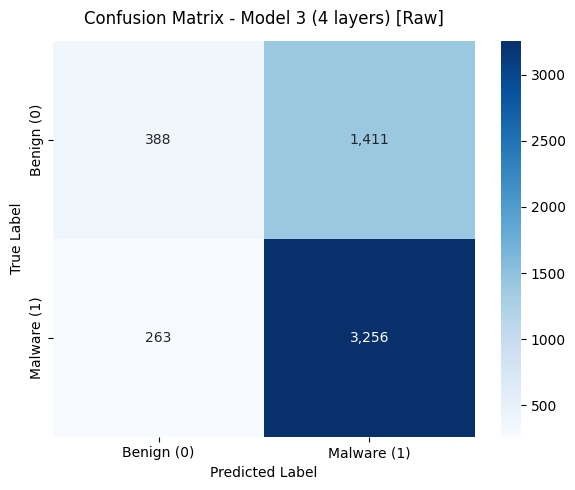


Classification Report (Test Set):
              precision    recall  f1-score   support

  Benign (0)       0.60      0.22      0.32      1799
 Malware (1)       0.70      0.93      0.80      3519

    accuracy                           0.69      5318
   macro avg       0.65      0.57      0.56      5318
weighted avg       0.66      0.69      0.63      5318



In [69]:
from sklearn.metrics import confusion_matrix, classification_report

best_row = df_results.loc[df_results['F1-Score'].idxmax()]
best_name = f"{best_row['Model']} [{best_row['Dataset']}]"
best_model = trained_models[best_name]

print(f"★ Best Performing Model: {best_name}")
print(f"  Test Accuracy: {best_row['Accuracy']:.4f} | Test F1-Score: {best_row['F1-Score']:.4f}\n")

X_tr_eval, X_te_eval = datasets[best_row['Dataset']]

train_preds = (best_model.predict(X_tr_eval, verbose=0) >= 0.5).astype(int).flatten()
test_preds = (best_model.predict(X_te_eval, verbose=0) >= 0.5).astype(int).flatten()

train_test_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Training Set": [
        f"{accuracy_score(y_train, train_preds):.4f}",
        f"{precision_score(y_train, train_preds):.4f}",
        f"{recall_score(y_train, train_preds):.4f}",
        f"{f1_score(y_train, train_preds):.4f}"
    ],
    "Testing Set": [
        f"{accuracy_score(y_test, test_preds):.4f}",
        f"{precision_score(y_test, test_preds):.4f}",
        f"{recall_score(y_test, test_preds):.4f}",
        f"{f1_score(y_test, test_preds):.4f}"
    ]
})

print("=" * 55)
print(f"Train vs. Test Set Performance: {best_name}")
print("=" * 55)
print(train_test_summary.to_string(index=False))

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt=',d', 
    cmap='Blues',
    xticklabels=['Benign (0)', 'Malware (1)'],
    yticklabels=['Benign (0)', 'Malware (1)']
)
plt.title(f"Confusion Matrix - {best_name}", fontsize=12, pad=12)
plt.xlabel("Predicted Label", fontsize=10)
plt.ylabel("True Label", fontsize=10)
plt.tight_layout()
plt.show()

print("\nClassification Report (Test Set):")
print(classification_report(y_test, test_preds, target_names=['Benign (0)', 'Malware (1)']))
